# **Linear Rregression**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
%matplotlib inline

warnings.filterwarnings(action='ignore')

In [ ]:
df = pd.read_csv('housing_data.csv')
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
df.shape

(506, 14)

In [ ]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [ ]:
nc = [feature for feature in df.columns if df[feature].dtype != 'O']
nc

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV']

In [ ]:
len(nc)

14

In [ ]:
for i in nc:
  df[i].fillna(df[i].median(), inplace=True)

df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


<Axes: >

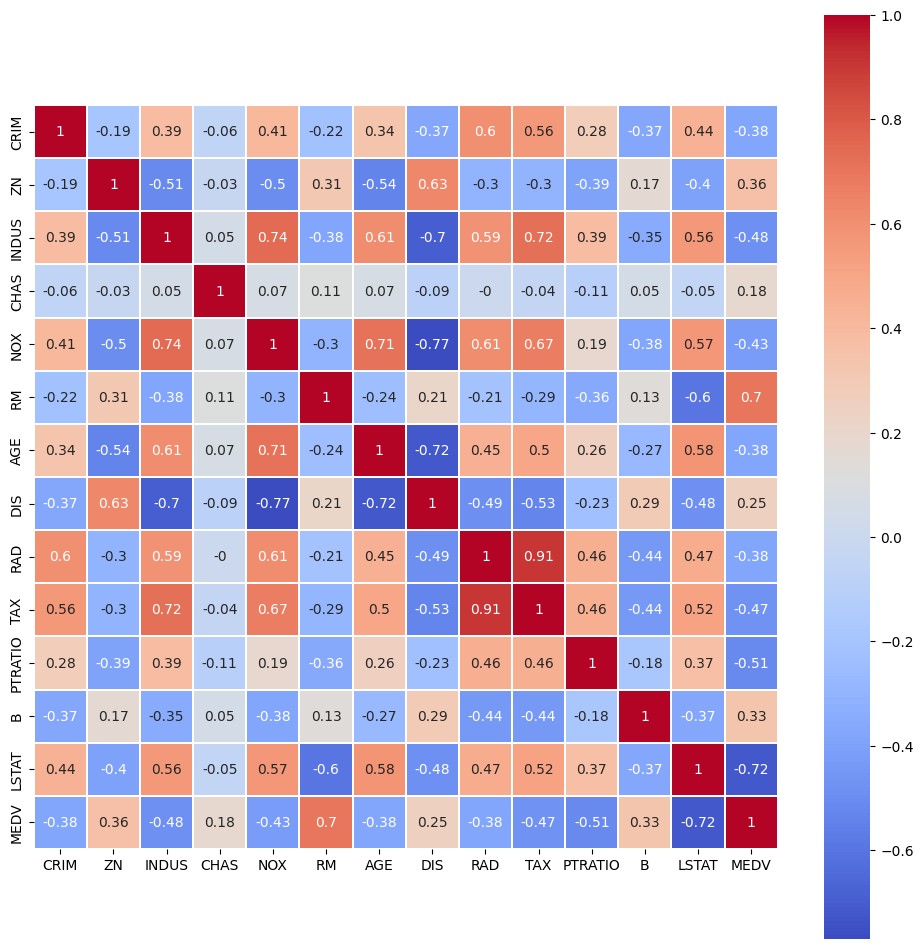

In [ ]:
plt.figure(figsize = (12,12))
sns.heatmap(data = df.corr().round(2),annot=True,linewidths=0.2,square=True, cmap='coolwarm')

In [ ]:
#using this: Lstat, medv, PTRation, RM, tax because of feature extraction and others are irrelevant
df1 = df[['RM','TAX','PTRATIO','LSTAT','MEDV']]
df1

,RM,TAX,PTRATIO,LSTAT,MEDV
0,6.575,296,15.3,4.98,24.0
1,6.421,242,17.8,9.14,21.6
2,7.185,242,17.8,4.03,34.7
3,6.998,222,18.7,2.94,33.4
4,7.147,222,18.7,11.43,36.2
...,...,...,...,...,...
501,6.593,273,21.0,11.43,22.4
502,6.120,273,21.0,9.08,20.6
503,6.976,273,21.0,5.64,23.9
504,6.794,273,21.0,6.48,22.0


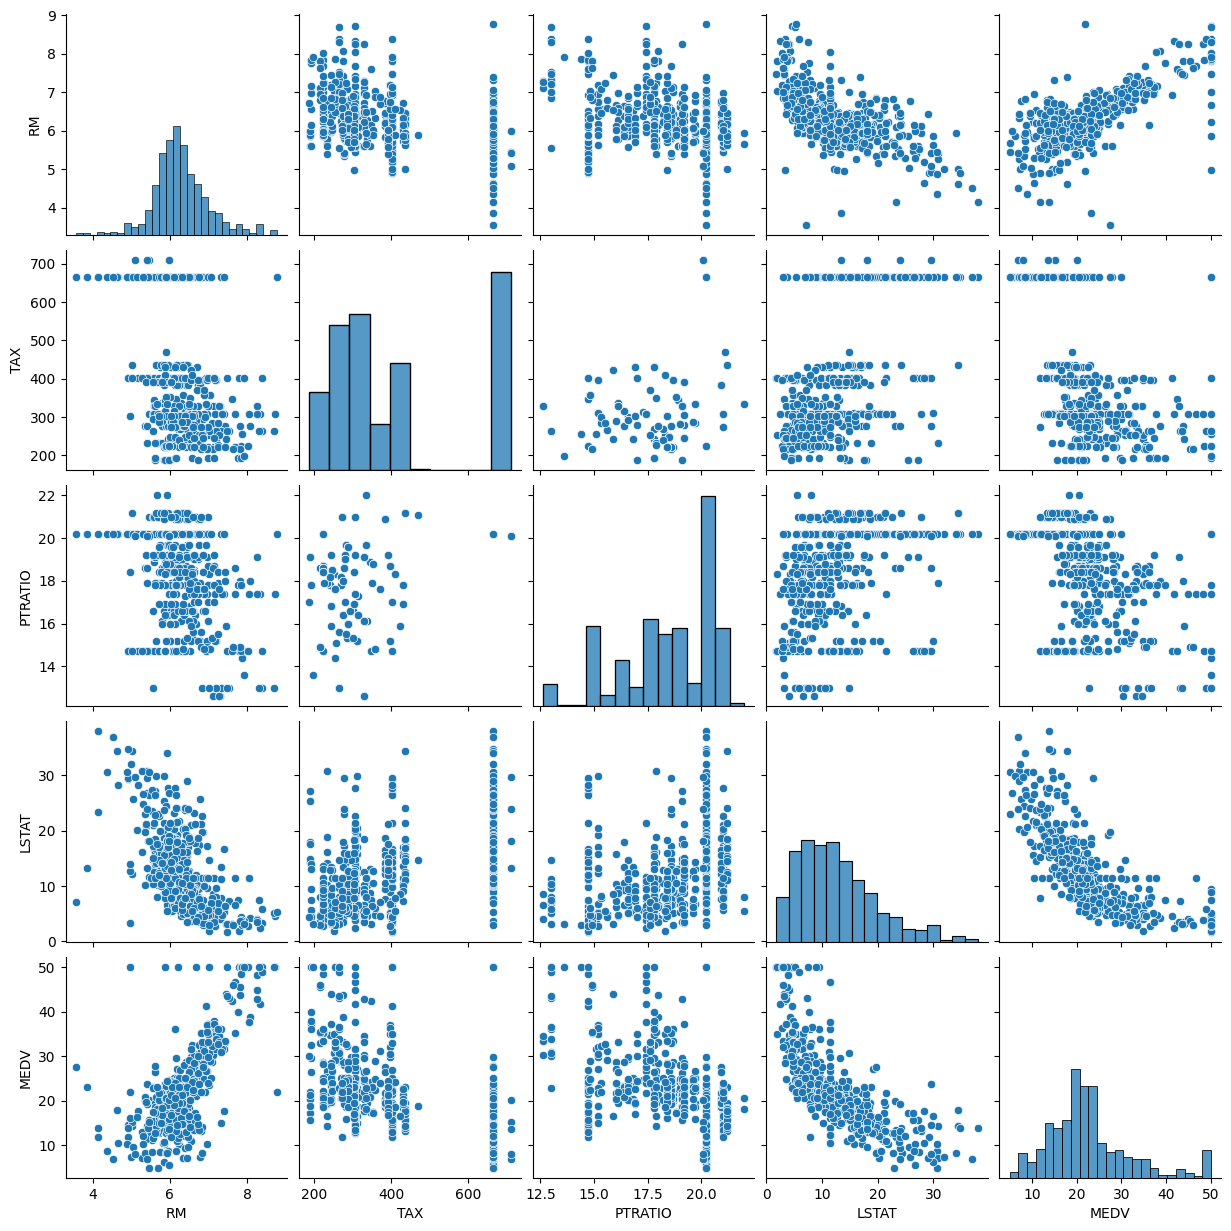

In [ ]:
sns.pairplot(data=df1)

In [ ]:
desc = df1.describe().round(2)
desc

,RM,TAX,PTRATIO,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00
mean,6.28,408.24,18.46,12.66,22.53
std,0.70,168.54,2.16,7.02,9.20
min,3.56,187.00,12.60,1.73,5.00
25%,5.89,279.00,17.40,7.23,17.02
50%,6.21,330.00,19.05,11.43,21.20
75%,6.62,666.00,20.20,16.57,25.00
max,8.78,711.00,22.00,37.97,50.00


Text(0.5, 1.0, 'Distribution plot of MEDV')

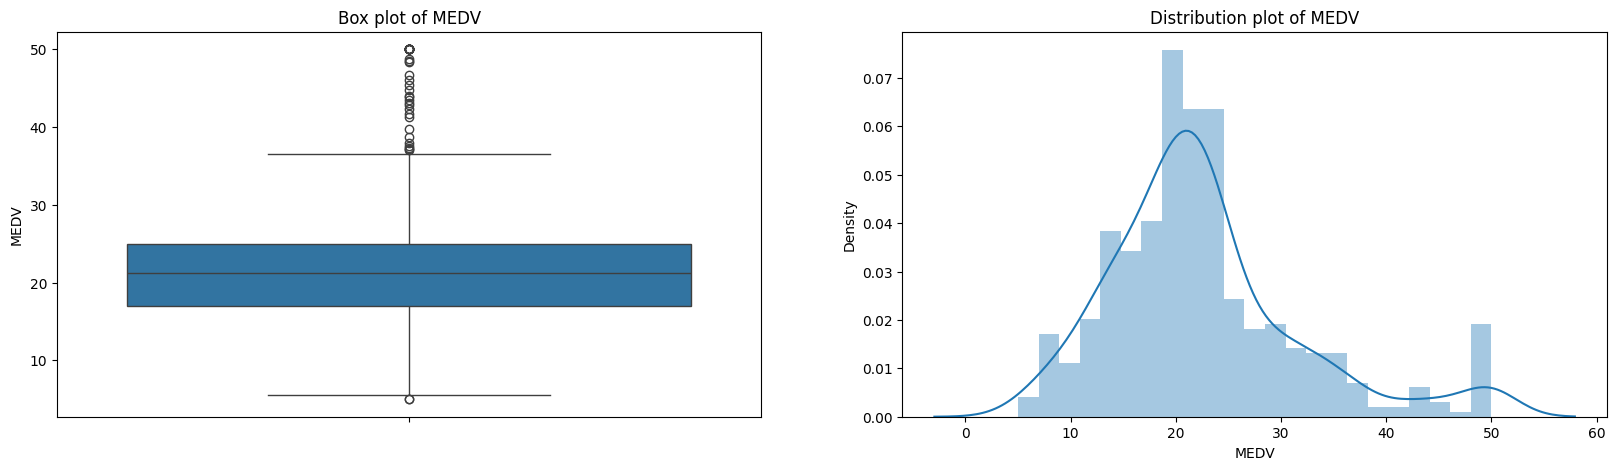

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)

sns.boxplot(df1.MEDV)
plt.title('Box plot of MEDV')

plt.subplot(1,2,2)
sns.distplot(df1.MEDV)
plt.title('Distribution plot of MEDV')

In [ ]:
#Finding Values Q3, Q2
MEDV_Q3 = desc['MEDV']['75%']
MEDV_Q1 = desc['MEDV']['25%']

#Finding Values for IQR, Lower Bound and Upper Bound
MEDV_IQR = MEDV_Q3 - MEDV_Q1
MEDV_UB = MEDV_Q3 + 1.5 * MEDV_IQR
MEDV_LB = MEDV_Q1 - 1.5 * MEDV_IQR

# print(f"Lower Bound: {MEDV_LB}")
# print(f"Upper Bound: {MEDV_UB}")

df1[df1['MEDV'] < MEDV_LB]

,RM,TAX,PTRATIO,LSTAT,MEDV
398,5.453,666,20.2,30.59,5.0
405,5.683,666,20.2,22.98,5.0


In [ ]:
df1[df1['MEDV'] > MEDV_UB].sort_values(by = ['MEDV','RM'])

,RM,TAX,PTRATIO,LSTAT,MEDV
190,6.951,398,15.2,5.10,37.0
179,6.980,193,17.8,5.04,37.2
291,7.148,245,19.2,3.56,37.3
226,8.040,307,17.4,11.43,37.6
182,7.155,193,17.8,4.82,37.9
97,8.069,276,18.0,4.21,38.7
180,7.765,193,17.8,7.56,39.8
157,6.943,403,14.7,4.59,41.3
232,8.337,307,17.4,2.47,41.7
202,7.610,348,14.7,3.11,42.3


In [ ]:
df1.shape

(506, 5)

In [ ]:
df2 = df1[~(df1['MEDV']==50)]
df2.shape

(490, 5)

Text(0.5, 1.0, 'Distribution plot of MEDV')

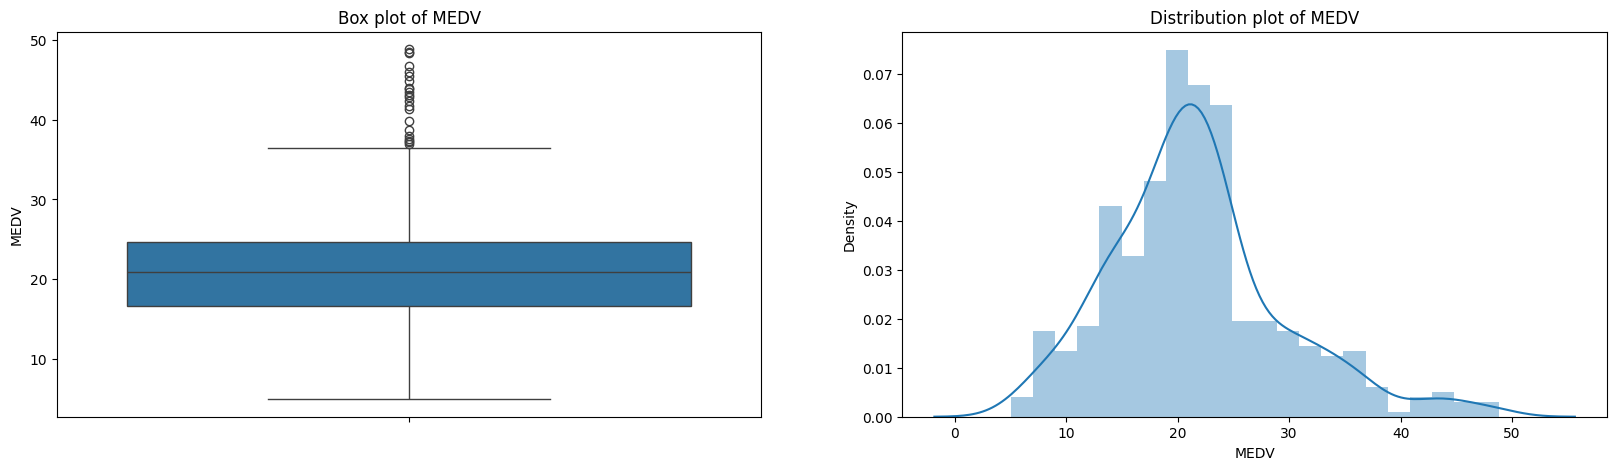

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.boxplot(df2.MEDV)
plt.title('Box plot of MEDV')

plt.subplot(1,2,2)
sns.distplot(df2.MEDV)
plt.title('Distribution plot of MEDV')

Text(0.5, 1.0, 'Scatterplot plot of TAX vs MEDV')

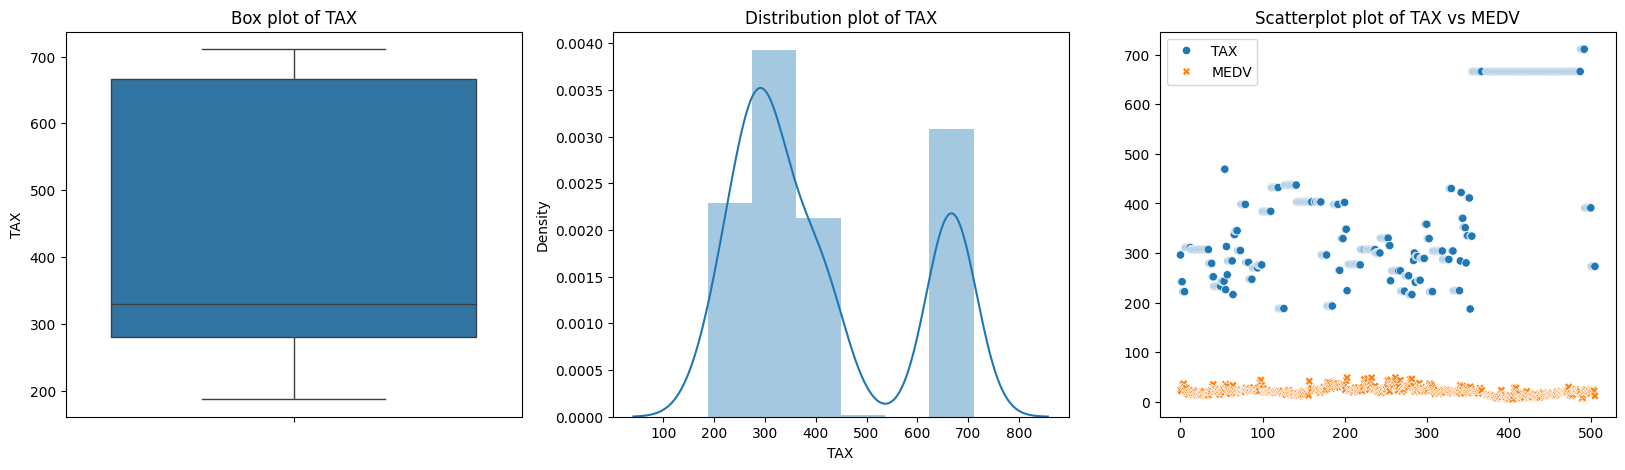

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)  # 1 row, 3 col, and plot 1st col
sns.boxplot(df2.TAX)
plt.title('Box plot of TAX')

plt.subplot(1,3,2) # 1 row, 3 col, and plot 2nd col
sns.distplot(df2.TAX)
plt.title('Distribution plot of TAX')

plt.subplot(1,3,3)
sns.scatterplot([df2.TAX,df2.MEDV]) # 1 row, 3 col, and plot 3rd
plt.title('Scatterplot plot of TAX vs MEDV')

In [ ]:
temp_df = df2[df1['TAX'] > 600].sort_values(by = ['RM','MEDV'])
print(temp_df.to_markdown())

|     |    RM |   TAX |   PTRATIO |   LSTAT |   MEDV |
|----:|------:|------:|----------:|--------:|-------:|
| 365 | 3.561 |   666 |      20.2 |    7.12 |   27.5 |
| 367 | 3.863 |   666 |      20.2 |   13.33 |   23.1 |
| 406 | 4.138 |   666 |      20.2 |   23.34 |   11.9 |
| 374 | 4.138 |   666 |      20.2 |   37.97 |   13.8 |
| 384 | 4.368 |   666 |      20.2 |   30.63 |    8.8 |
| 414 | 4.519 |   666 |      20.2 |   36.98 |    7   |
| 412 | 4.628 |   666 |      20.2 |   34.37 |   17.9 |
| 386 | 4.652 |   666 |      20.2 |   28.28 |   10.5 |
| 388 | 4.88  |   666 |      20.2 |   30.62 |   10.2 |
| 373 | 4.906 |   666 |      20.2 |   34.77 |   13.8 |
| 366 | 4.963 |   666 |      20.2 |   14    |   21.9 |
| 387 | 5     |   666 |      20.2 |   31.99 |    7.4 |
| 392 | 5.036 |   666 |      20.2 |   25.68 |    9.7 |
| 490 | 5.093 |   711 |      20.1 |   29.68 |    8.1 |
| 413 | 5.155 |   666 |      20.2 |   20.08 |   16.3 |
| 385 | 5.277 |   666 |      20.2 |   30.81 |    7.2 |
| 417 | 5.

In [ ]:
temp_df.describe()

,RM,TAX,PTRATIO,LSTAT,MEDV
count,132.000000,132.000000,132.000000,132.000000,132.000000
mean,6.000689,667.704545,20.196212,18.828864,14.994697
std,0.712621,8.623365,0.019163,6.590380,5.405825
min,3.561000,666.000000,20.100000,5.290000,5.000000
25%,5.674250,666.000000,20.200000,14.175000,10.900000
50%,6.139500,666.000000,20.200000,17.910000,14.100000
75%,6.407250,666.000000,20.200000,23.052500,19.200000
max,8.780000,711.000000,20.200000,37.970000,29.800000


In [ ]:
tax_10 = df2[(df2['TAX'] < 600) & (df2['LSTAT'] >= 0) & (df2['LSTAT'] < 10)]['TAX'].mean()
tax_20 = df2[(df2['TAX'] < 600) & (df2['LSTAT'] >= 10) & (df2['LSTAT'] < 20)]['TAX'].mean()
tax_30 = df2[(df2['TAX'] < 600) & (df2['LSTAT'] >= 20) & (df2['LSTAT'] < 30)]['TAX'].mean()
tax_40 = df2[(df2['TAX'] < 600) & (df2['LSTAT'] >= 30) & (df2['LSTAT'] < 40)]['TAX'].mean()

indexes = list(df2.index)

for i in indexes:
    if df2['TAX'][i] > 600:
        if (0 <= df2['LSTAT'][i] < 10):
            df2.at[i,'TAX'] = tax_10
        elif (10 <= df2['LSTAT'][i] < 20):
            df2.at[i,'TAX'] = tax_20
        elif (20 <= df2['LSTAT'][i] < 30):
            df2.at[i,'TAX'] = tax_30
        elif (df2['LSTAT'][i] > 30):
            df2.at[i,'TAX'] = tax_40

print('Values imputed successfully')


Values imputed successfully


In [ ]:
df2[df2['TAX'] > 600]['TAX'].count()

np.int64(0)

Text(0.5, 1.0, 'Scatterplot plot of TAX vs MEDV')

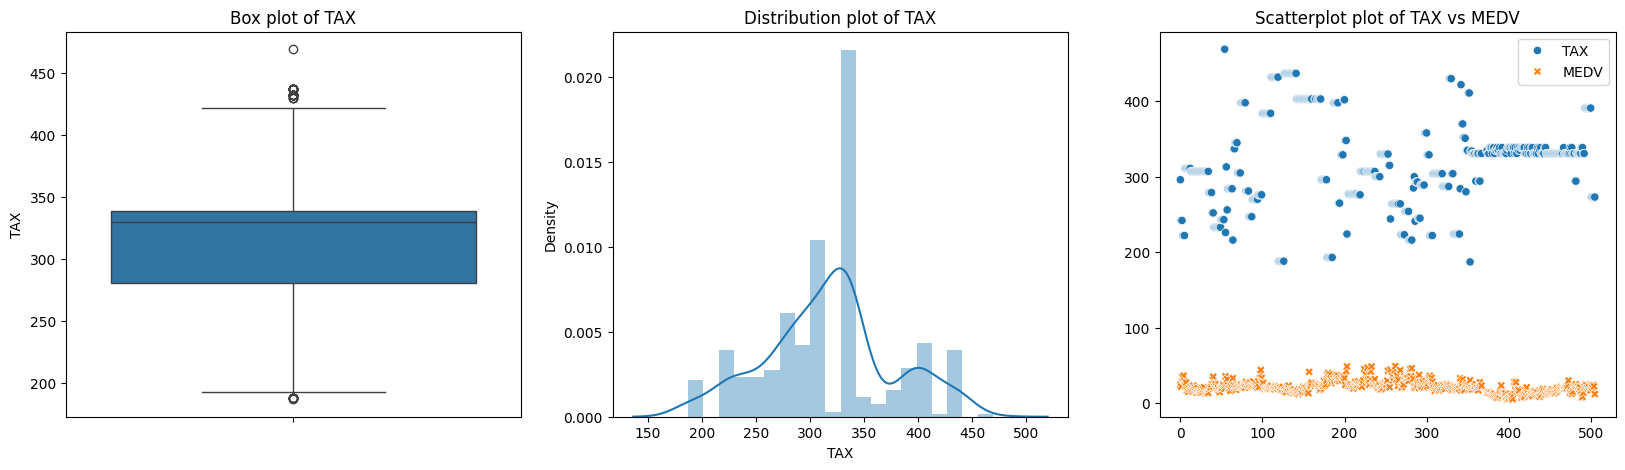

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)  # 1 row, 3 col, and plot 1st col
sns.boxplot(df2.TAX)
plt.title('Box plot of TAX')

plt.subplot(1,3,2) # 1 row, 3 col, and plot 2nd col
sns.distplot(df2.TAX)
plt.title('Distribution plot of TAX')

plt.subplot(1,3,3)
sns.scatterplot([df2.TAX,df2.MEDV]) # 1 row, 3 col, and plot 3rd
plt.title('Scatterplot plot of TAX vs MEDV')

In [ ]:
temp_df = df2[df1['TAX'] > 600].sort_values(by=['RM', 'MEDV'])

temp_df

,RM,TAX,PTRATIO,LSTAT,MEDV
365,3.561,294.139785,20.2,7.12,27.5
367,3.863,330.770270,20.2,13.33,23.1
406,4.138,338.636364,20.2,23.34,11.9
374,4.138,335.000000,20.2,37.97,13.8
384,4.368,335.000000,20.2,30.63,8.8
...,...,...,...,...,...
473,6.980,330.770270,20.2,11.43,29.8
482,7.061,294.139785,20.2,7.01,25.0
375,7.313,330.770270,20.2,13.44,15.0
453,7.393,330.770270,20.2,16.74,17.8


In [ ]:
temp_df.describe()

,RM,TAX,PTRATIO,LSTAT,MEDV
count,132.000000,132.000000,132.000000,132.000000,132.000000
mean,6.000689,331.908076,20.196212,18.828864,14.994697
std,0.712621,8.291618,0.019163,6.590380,5.405825
min,3.561000,294.139785,20.100000,5.290000,5.000000
25%,5.674250,330.770270,20.200000,14.175000,10.900000
50%,6.139500,330.770270,20.200000,17.910000,14.100000
75%,6.407250,338.636364,20.200000,23.052500,19.200000
max,8.780000,338.636364,20.200000,37.970000,29.800000


In [ ]:
temp_df[temp_df['TAX'] == 666].value_counts()

,,,,,count
RM,TAX,PTRATIO,LSTAT,MEDV,


In [ ]:
TAX_10=df2[(df2['TAX']<600)&(df2['LSTAT']>=0)&(df2['LSTAT']<10)]['TAX'].mean()
TAX_20=df2[(df2['TAX']<600)&(df2['LSTAT']>=10)&(df2['LSTAT']<20)]['TAX'].mean()
TAX_30=df2[(df2['TAX']<600)&(df2['LSTAT']>=20)&(df2['LSTAT']<30)]['TAX'].mean()
TAX_40=df2[(df2['TAX']<600)&(df2['LSTAT']>=30)&(df2['LSTAT']<40)]['TAX'].mean()

indexes = list(df2.index)
for i in indexes:
    if df2['TAX'][i] > 600:
        if (0 <= df2['LSTAT'][i] < 10):
            df2.at[i,'TAX'] = TAX_10
        elif (10 <= df2['LSTAT'][i] < 20):
            df2.at[i,'TAX'] = TAX_20
        elif (20 <= df2['LSTAT'][i] < 30):
            df2.at[i,'TAX'] = TAX_30
        elif (df2['LSTAT'][i] >30):
            df2.at[i,'TAX'] = TAX_40

print('Values imputed successfully')

Values imputed successfully


In [ ]:
df2[df2["TAX"] > 600]['TAX'].count()

np.int64(0)

Text(0.5, 1.0, 'Scatterplot plot of PTRATIO vs MEDV')

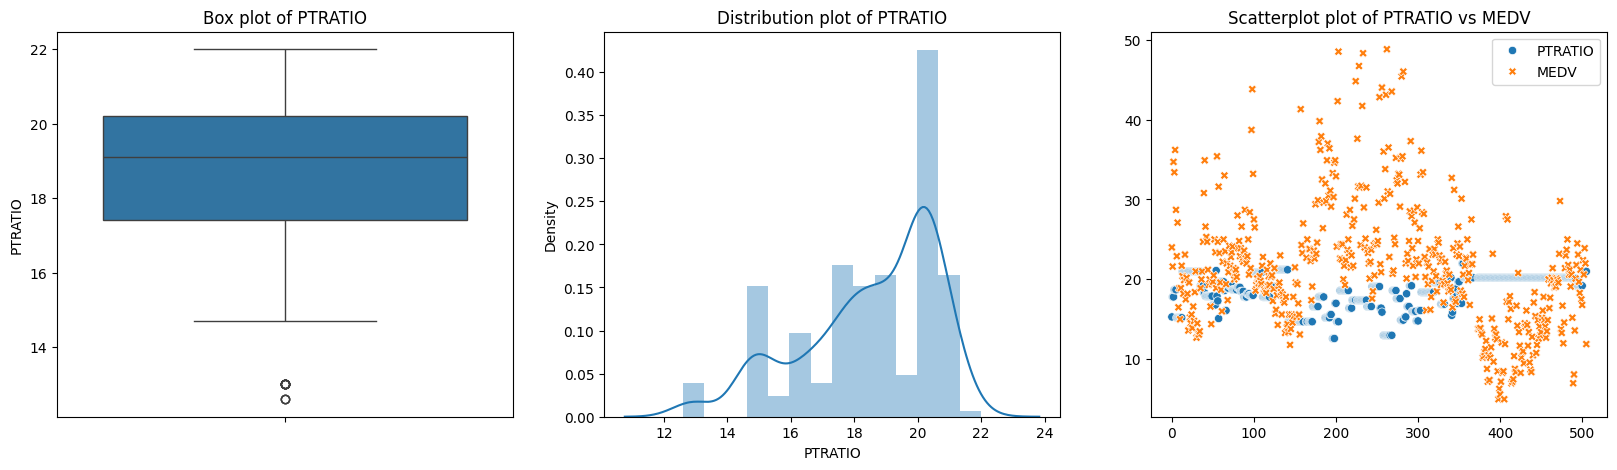

In [ ]:
plt.figure(figsize=(20,5))
plt.subplot(1,3,1)  # 1 row, 3 col, and plot 1st col
sns.boxplot(df2.PTRATIO)
plt.title('Box plot of PTRATIO')

plt.subplot(1,3,2) # 1 row, 3 col, and plot 2nd col
sns.distplot(df2.PTRATIO)
plt.title('Distribution plot of PTRATIO')

plt.subplot(1,3,3)
sns.scatterplot([df2.PTRATIO,df2.MEDV]) # 1 row, 3 col, and plot 3rd
plt.title('Scatterplot plot of PTRATIO vs MEDV')

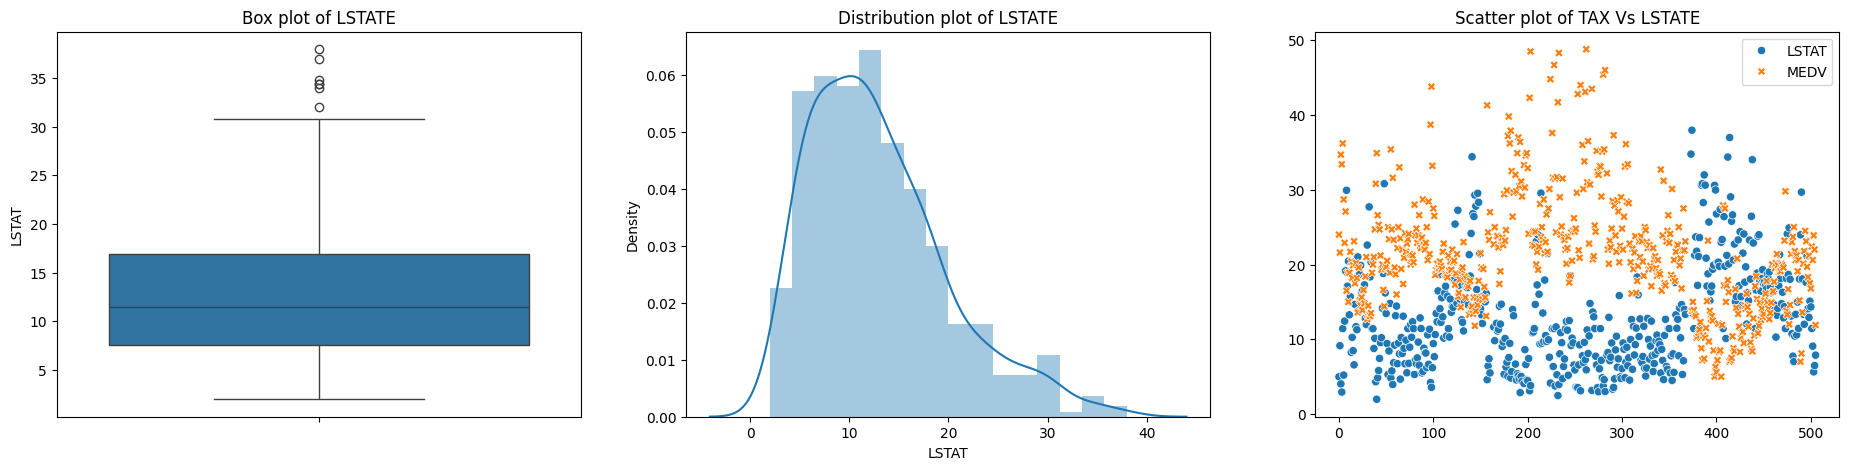

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(23,5))

plt.subplot(1,3,1)

sns.boxplot(df2.LSTAT)

plt.title("Box plot of LSTATE")

#--------------------------------

plt.subplot(1, 3, 2)

sns.distplot(df2.LSTAT)

plt.title("Distribution plot of LSTATE")

#-------------------------------

plt.subplot(1, 3, 3)

sns.scatterplot([ df2.LSTAT, df2.MEDV])

plt.title("Scatter plot of TAX Vs LSTATE")

plt.show()

In [ ]:
LSTAT_Q3 = desc["LSTAT"]['75%']
LSTAT_Q1 = desc["LSTAT"]['25%']

LSTAT_IQR = LSTAT_Q3 - LSTAT_Q1

LSTAT_UB = LSTAT_Q3 + 1.5*LSTAT_IQR

LSTAT_LB = LSTAT_Q1 - 1.5*LSTAT_IQR

df1[df1["LSTAT"] < LSTAT_LB]

,RM,TAX,PTRATIO,LSTAT,MEDV


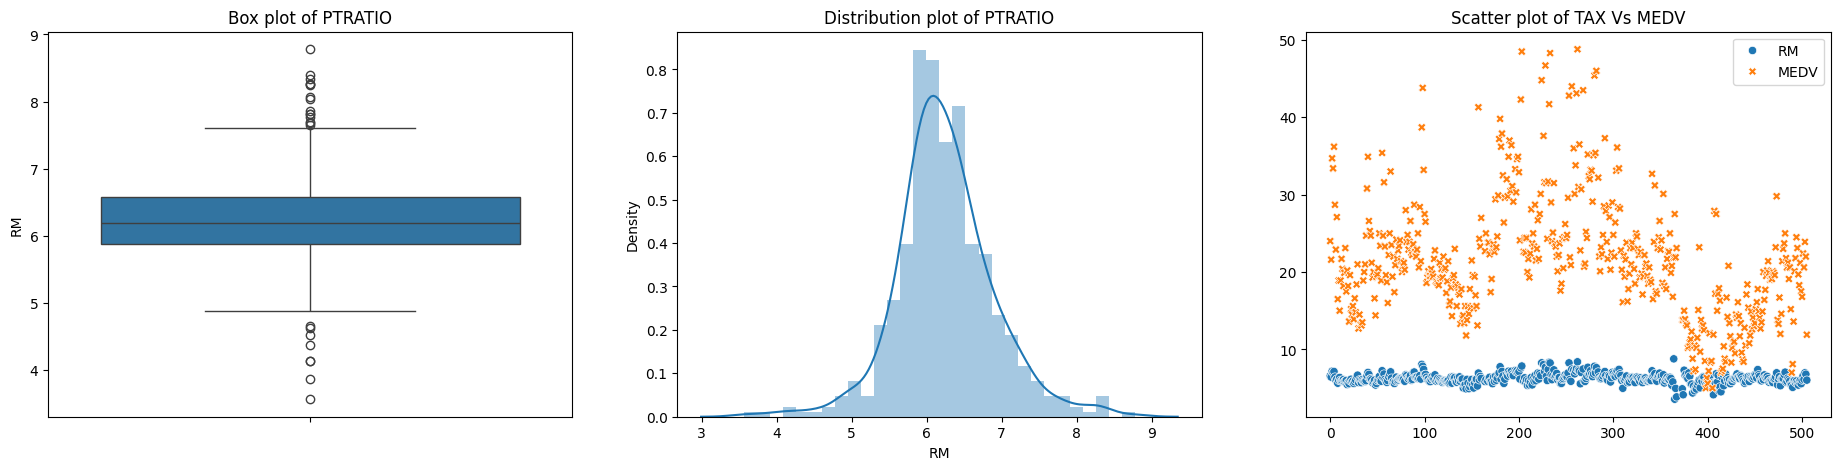

In [ ]:
plt.figure(figsize=(23,5))

plt.subplot(1,3,1)

sns.boxplot(df2.RM)

plt.title("Box plot of PTRATIO")

#--------------------------------

plt.subplot(1, 3, 2)

sns.distplot(df2.RM)

plt.title("Distribution plot of PTRATIO")

#-------------------------------

plt.subplot(1, 3, 3)

sns.scatterplot([ df2.RM, df2.MEDV])

plt.title("Scatter plot of TAX Vs MEDV")

plt.show()

In [ ]:
RM_Q3 = desc["RM"]['75%']
RM_Q1 = desc["RM"]['25%']
RM_IQR = RM_Q3 - RM_Q1
RM_UB = RM_Q3 + 1.5*RM_IQR
RM_LB = RM_Q1 - 1.5*RM_IQR

df1[df1["RM"] < RM_LB].sort_values(by=['RM' , 'LSTAT'])
df1[df1["RM"] > RM_UB].sort_values(by=['RM' , 'LSTAT'])

,RM,TAX,PTRATIO,LSTAT,MEDV
180,7.765,193,17.8,7.56,39.8
162,7.802,403,14.7,1.92,50.0
98,7.820,276,18.0,3.57,43.8
280,7.820,216,14.9,3.76,45.4
186,7.831,193,17.8,4.45,50.0
203,7.853,224,14.7,3.81,48.5
195,7.875,255,14.4,2.97,50.0
283,7.923,198,13.6,3.16,50.0
166,7.929,403,14.7,3.70,50.0
204,8.034,224,14.7,2.88,50.0


In [ ]:
df3=df2.drop(axis=0 , index=[364, 365 , 367])

df3

,RM,TAX,PTRATIO,LSTAT,MEDV
0,6.575,296.0,15.3,4.98,24.0
1,6.421,242.0,17.8,9.14,21.6
2,7.185,242.0,17.8,4.03,34.7
3,6.998,222.0,18.7,2.94,33.4
4,7.147,222.0,18.7,11.43,36.2
...,...,...,...,...,...
501,6.593,273.0,21.0,11.43,22.4
502,6.120,273.0,21.0,9.08,20.6
503,6.976,273.0,21.0,5.64,23.9
504,6.794,273.0,21.0,6.48,22.0


In [ ]:
df3.shape

(487, 5)

In [ ]:
X = df3.iloc[:,0:4].values
y = df3.iloc[:,-1:].values


print(f"Shape of Dependent Variable X = {X.shape}")
print(f"Shape of Independent Variable y = {y.shape}")

Shape of Dependent Variable X = (487, 4)
Shape of Independent Variable y = (487, 1)


In [ ]:
def FeatureScaling(X):
    """
    is function takes an array as an input, which needs to be scaled down.
    Apply Standardization technique to it and scale down the features with mean = 0 and standard deviation = 1

    Input <- 2 dimensional numpy array
    Returns -> Numpy array after applying Feature Scaling
    """
    mean = np.mean(X,axis=0)
    std = np.std(X,axis=0)
    for i in range(X.shape[1]):
        X[:,i] = (X[:,i]-mean[i])/std[i]

    return X


X = FeatureScaling(X)

m,n = X.shape
X = np.append(arr=np.ones((m,1)),values=X,axis=1)


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

print(f"Shape of X_train = {X_train.shape}")
print(f"Shape of X_test = {X_test.shape}")
print(f"Shape of y_train = {y_train.shape}")
print(f"Shape of y_test = {y_test.shape}")

Shape of X_train = (389, 5)
Shape of X_test = (98, 5)
Shape of y_train = (389, 1)
Shape of y_test = (98, 1)


In [ ]:
def ComputeCost(X,y,theta):
    """
    This function takes three inputs and uses the Cost Function to determine the cost (basically error of prediction vs
    actual values)
    Cost Function: Sum of square of error in predicted values divided by number of data points in the set
    J = 1/(2*m) *  Summation(Square(Predicted values - Actual values))

    Input <- Take three numoy array X,y and theta
    Return -> The cost calculated from the Cost Function
    """
    m=X.shape[0] #number of data points in the set
    J = (1/(2*m)) * np.sum((X.dot(theta) - y)**2)
    return J

In [ ]:
def GradientDescent(X,y,theta,alpha,no_of_iters):
    """
    Gradient Descent Algorithm to minimize the Cost

    Input <- X, y and theta are numpy arrays
            X -> Independent Variables/ Features
            y -> Dependent/ Target Variable
            theta -> Parameters
            alpha -> Learning Rate i.e. size of each steps we take
            no_of_iters -> Number of iterations we want to perform

    Return -> theta (numpy array) which are the best parameters for our dataset to fit a linear line
             and Cost Computed (numpy array) for each iteration
    """
    m=X.shape[0]
    J_Cost = []
    for i in range(no_of_iters):
        error = np.dot(X.transpose(),(X.dot(theta)-y))
        theta = theta - alpha * (1/m) * error
        J_Cost.append(ComputeCost(X,y,theta))

    return theta, np.array(J_Cost)

In [ ]:
iters = 1000

alpha1 = 0.001
theta1 = np.zeros((X_train.shape[1],1))
theta1, J_Costs1 = GradientDescent(X_train,y_train,theta1,alpha1,iters)

#-----------------------------------------------------------------------------------------------

alpha2 = 0.003
theta2 = np.zeros((X_train.shape[1],1))
theta2, J_Costs2 = GradientDescent(X_train,y_train,theta2,alpha2,iters)

#-----------------------------------------------------------------------------------------------

alpha3 = 0.01
theta3 = np.zeros((X_train.shape[1],1))
theta3, J_Costs3 = GradientDescent(X_train,y_train,theta3,alpha3,iters)

#-----------------------------------------------------------------------------------------------

alpha4 = 0.03
theta4 = np.zeros((X_train.shape[1],1))
theta4, J_Costs4 = GradientDescent(X_train,y_train,theta4,alpha4,iters)

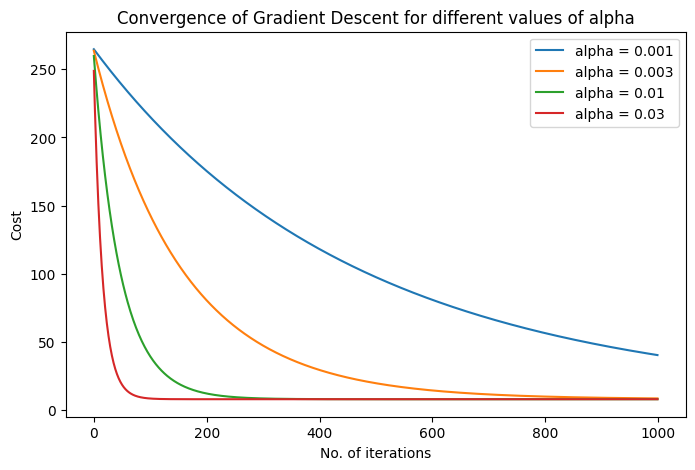

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(J_Costs1,label = 'alpha = 0.001')
plt.plot(J_Costs2,label = 'alpha = 0.003')
plt.plot(J_Costs3,label = 'alpha = 0.01')
plt.plot(J_Costs4,label = 'alpha = 0.03')
plt.title('Convergence of Gradient Descent for different values of alpha')
plt.xlabel('No. of iterations')
plt.ylabel('Cost')
plt.legend()
plt.show()

In [ ]:
theta4

array([[21.73546011],
       [ 2.86076194],
       [-1.078047  ],
       [-1.96051041],
       [-2.87113215]])

In [ ]:
def Predict(X,theta):
    """
    This function predicts the result for the unseen data
    """
    y_pred = X.dot(theta)
    return y_pred


In [ ]:
y_pred = Predict(X_test,theta4)
y_pred[:5]

array([[23.54777745],
       [28.09399088],
       [16.16554384],
       [18.97965458],
       [17.66976105]])

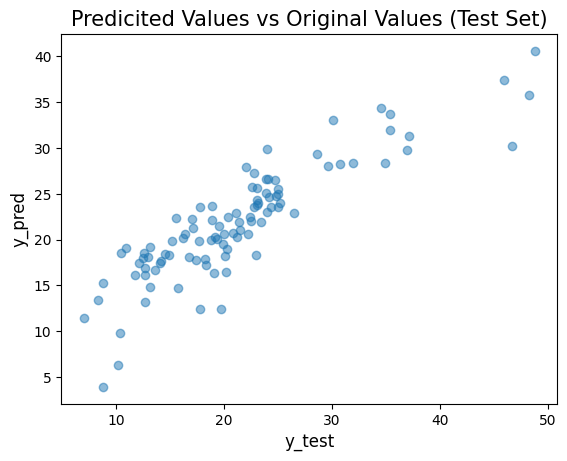

In [ ]:
plt.scatter(x=y_test,y=y_pred,alpha=0.5)
plt.xlabel('y_test',size=12)
plt.ylabel('y_pred',size=12)
plt.title('Predicited Values vs Original Values (Test Set)',size=15)
plt.show()

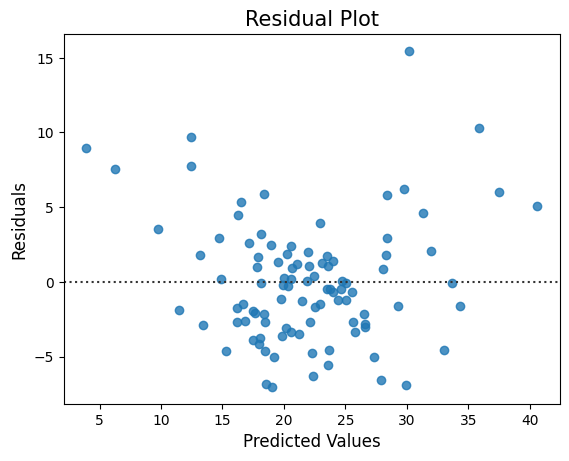

In [ ]:
sns.residplot(x=y_pred, y=y_test - y_pred)

plt.xlabel('Predicted Values', size=12)
plt.ylabel('Residuals', size=12)
plt.title('Residual Plot', size=15)
plt.show()

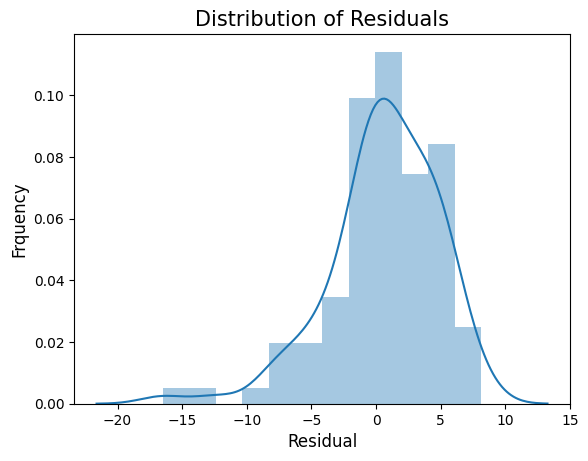

In [ ]:
sns.distplot(y_pred-y_test)
plt.xlabel('Residual',size=12)
plt.ylabel('Frquency',size=12)
plt.title('Distribution of Residuals',size=15)
plt.show()

In [ ]:
from sklearn import metrics
r2= metrics.r2_score(y_test,y_pred)
N,p = X_test.shape
adj_r2 = 1-((1-r2)*(N-1))/(N-p-1)
print(f'R^2 = {r2}')
print(f'Adjusted R^2 = {adj_r2}')

R^2 = 0.7467879874493435
Adjusted R^2 = 0.7330264650281122


In [ ]:
from sklearn import metrics
mse = metrics.mean_squared_error(y_test,y_pred)
mae = metrics.mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test,y_pred))
print(f'Mean Squared Error: {mse}',f'Mean Absolute Error: {mae}',f'Root Mean Squared Error: {rmse}',sep='\n')

Mean Squared Error: 18.27759183945454
Mean Absolute Error: 3.2403659815833694
Root Mean Squared Error: 4.275230033513348


Text(0.5, 1.0, ' SCATTER PLOT OF LSTAT')

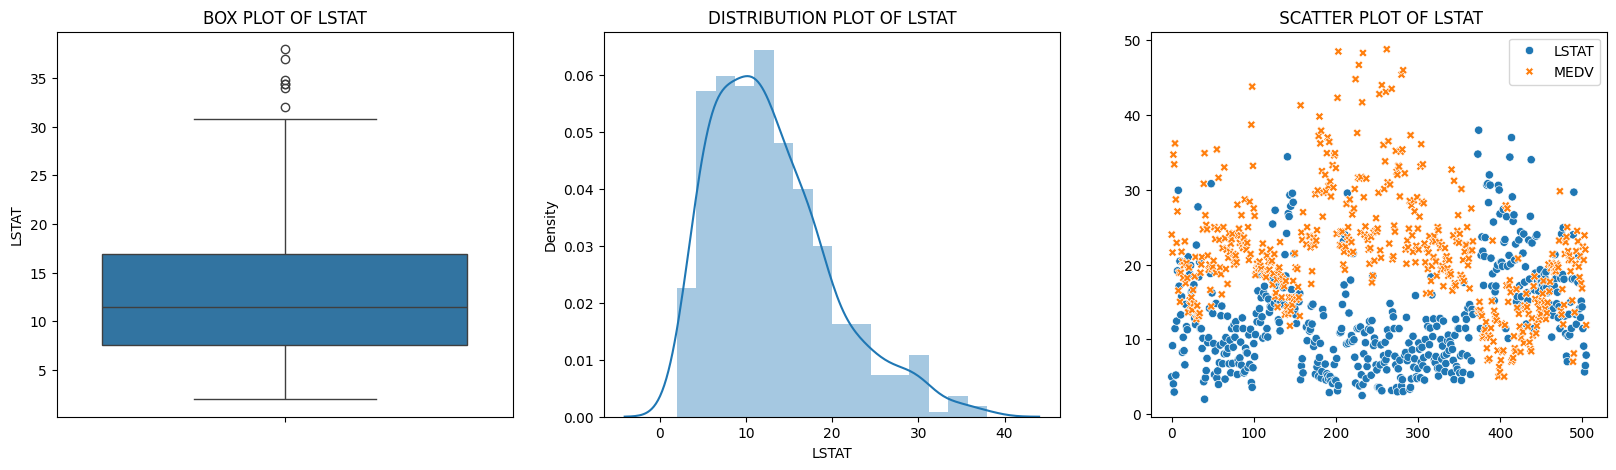

In [ ]:
#coefficients of regression model
coeff=np.array([y for x in theta4 for y in x]).round(2)
plt.figure(figsize=(20,5))

#----------------------------------------------------------------------

plt.subplot(1,3,1)
sns.boxplot(df2.LSTAT)
plt.title('BOX PLOT OF LSTAT')

#---------------------------------------------------------------------

plt.subplot(1,3,2)
sns.distplot(df2.LSTAT)
plt.title('DISTRIBUTION PLOT OF LSTAT')

#---------------------------------------------------------------------

plt.subplot(1,3,3)
sns.scatterplot([df2.LSTAT,df2.MEDV])
plt.title(' SCATTER PLOT OF LSTAT')

In [ ]:
features=['Bias','RM','TAX','PTRATIO','LSTAT']
eqn = 'MEDV = '
for f,c in zip(features,coeff):
    eqn+=f" + ({c} * {f})";

print(eqn)

MEDV =  + (21.74 * Bias) + (2.86 * RM) + (-1.08 * TAX) + (-1.96 * PTRATIO) + (-2.87 * LSTAT)


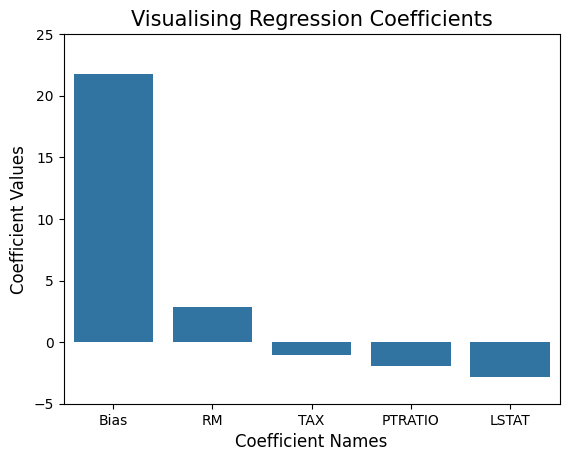

In [ ]:
sns.barplot(x=features,y=coeff)
plt.ylim([-5,25])
plt.xlabel('Coefficient Names',size=12)
plt.ylabel('Coefficient Values',size=12)
plt.title('Visualising Regression Coefficients',size=15)
plt.show()